# Import Library

In [146]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, RandomizedSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score
from xgboost import XGBClassifier
from scipy.stats import randint, uniform

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
import warnings
warnings.filterwarnings("ignore")
%matplotlib inline

# Import Dataset 

In [147]:
df= pd.read_csv("C:/Uner/Lomba/ArcVidya/Warm up/train.csv")
df_test = pd.read_csv("C:/Uner/Lomba/ArcVidya/Warm up/test.csv")

##### Terdapat 2 dataset yaitu dataset asli, dan dataset test untuk model

# Cek Nilai Unik pada Dataframe
##### Fungsinya untuk cek apakah data cenderung membentuk sebuah kluster

In [148]:
df = df.drop(columns=["id"])
df_test = df_test.drop(columns=["id"])
df.nunique()

Negara/Tahun                                   5603
Emisi Savanna Api                              2919
Emisi Kebakaran Hutan                          2364
Emisi Residu Tanaman                           4321
Emisi Budidaya Padi                            2943
Emisi Tanah Organik Yang Dikeringkan (Co2)     1711
Emisi Pembuatan Pestisida                      1134
Emisi Transportasi Makanan                     5223
Lahan Hutan                                     471
Konversi Hutan Bersih                           342
Emisi Konsumsi Rumah Tangga Makanan            5090
Emisi Ritel Makanan                            5184
Emisi Penggunaan Listrik Di Pertanian          4312
Emisi Kemasan Makanan                          2934
Emisi Sistem Agrifood Pembuangan Limbah        5163
Emisi Pengolahan Makanan                       2779
Emisi Manufaktur Pupuk                         2414
Emisi IPPU                                     4854
Emisi Kotoran Diterapkan Pada Tanah            4753
Emisi Pupuk 

In [149]:
df.head(51)

,Negara/Tahun,Emisi Savanna Api,Emisi Kebakaran Hutan,Emisi Residu Tanaman,Emisi Budidaya Padi,Emisi Tanah Organik Yang Dikeringkan (Co2),Emisi Pembuatan Pestisida,Emisi Transportasi Makanan,Lahan Hutan,Konversi Hutan Bersih,...,Emisi Manajemen Pupuk,Emisi Kebakaran Di Tanah Organik,Emisi Kebakaran Di Hutan Tropis Yang Lembab,Penggunaan Energi Di Pertanian,Populasi Pedesaan,Populasi Perkotaan,Total Populasi - Pria,Total Populasi - Wanita,Emisi Total,Peningkatan Suhu Rata - Rata
0,Afghanistan/1990,14.7237,0.0557,205.6077,686.000000,0.0000,11.807483,63.1152,-2388.8030,0.0000,...,319.1763,0.0,0.0,NaN,9655167.0,2593947.0,5348387.0,5346409.0,2198.963539,0.536167
1,Afghanistan/1991,14.7237,0.0557,209.4971,678.160000,0.0000,11.712073,61.2125,-2388.8030,0.0000,...,342.3079,0.0,0.0,NaN,10230490.0,2763167.0,5372959.0,5372208.0,2323.876629,0.020667
2,Afghanistan/1992,14.7237,0.0557,196.5341,686.000000,0.0000,11.712073,53.3170,-2388.8030,0.0000,...,349.1224,0.0,0.0,NaN,10995568.0,2985663.0,6028494.0,6028939.0,2356.304229,-0.259583
3,Afghanistan/1993,14.7237,0.0557,230.8175,686.000000,0.0000,11.712073,54.3617,-2388.8030,0.0000,...,352.2947,0.0,0.0,NaN,11858090.0,3237009.0,7003641.0,7000119.0,2368.470529,0.101917
4,Afghanistan/1994,14.7237,0.0557,242.0494,705.600000,0.0000,11.712073,53.9874,-2388.8030,0.0000,...,367.6784,0.0,0.0,NaN,12690115.0,3482604.0,7733458.0,7722096.0,2500.768729,0.372250
5,Afghanistan/1995,14.7237,0.0557,243.8152,666.400000,0.0000,11.712073,54.6445,-2388.8030,0.0000,...,397.5498,0.0,0.0,NaN,13401971.0,3697570.0,8219467.0,8199445.0,2624.612529,0.285583
6,Afghanistan/1996,38.9302,0.2014,249.0364,686.000000,0.0000,11.712073,53.1637,-2388.8030,0.0000,...,465.2050,0.0,0.0,NaN,13952791.0,3870093.0,8569175.0,8537421.0,2838.921329,0.036583
7,Afghanistan/1997,30.9378,0.1193,276.2940,705.600000,0.0000,11.712073,52.0390,-2388.8030,0.0000,...,511.5927,0.0,0.0,NaN,14373573.0,4008032.0,8916862.0,8871958.0,3204.180115,0.415167
8,Afghanistan/1998,64.1411,0.3263,287.4346,705.600000,0.0000,11.712073,52.7050,-2388.8030,0.0000,...,541.6598,0.0,0.0,NaN,14733655.0,4130344.0,9275541.0,9217591.0,3560.716661,0.890833
9,Afghanistan/1999,46.1683,0.0895,247.4980,548.800000,0.0000,11.712073,35.7630,-2388.8030,0.0000,...,611.0611,0.0,0.0,NaN,15137497.0,4266179.0,9667811.0,9595036.0,3694.806533,1.058500


##### Dataset ini memuat mengenai emisi CO2 dari sektor agri-pangan. Sektor agri-pangan terdiri dari: produksi, pengolahan, dan distribusi makanan yang memerlukan sumber daya alam, energi, dan emisi yang cukup besar, berkontribusi secara signifikan terhadap pemanasan global. 

In [150]:
df_test.head()

,Negara/Tahun,Emisi Savanna Api,Emisi Kebakaran Hutan,Emisi Residu Tanaman,Emisi Budidaya Padi,Emisi Tanah Organik Yang Dikeringkan (Co2),Emisi Pembuatan Pestisida,Emisi Transportasi Makanan,Lahan Hutan,Konversi Hutan Bersih,...,Emisi Pupuk Kandang Di Padang Rumput,Emisi Manajemen Pupuk,Emisi Kebakaran Di Tanah Organik,Emisi Kebakaran Di Hutan Tropis Yang Lembab,Penggunaan Energi Di Pertanian,Populasi Pedesaan,Populasi Perkotaan,Total Populasi - Pria,Total Populasi - Wanita,Emisi Total
0,Afghanistan/2015,0.8454,0.0,403.3181,642.8800,0.0,81.852555,440.0315,-246.2191,0.0,...,2719.1528,797.9007,0.0,0.0,NaN,25368923.0,8367571.0,17071446.0,16682054.0,12652.876111
1,Afghanistan/2016,1.6558,0.0,387.6130,466.4800,0.0,54.909681,340.8931,154.6574,0.0,...,2692.9570,793.9377,0.0,0.0,NaN,25985093.0,8670939.0,17520861.0,17115346.0,12988.384380
2,Afghanistan/2017,0.4015,0.0,344.6447,429.0518,0.0,55.148427,345.7609,154.6574,0.0,...,2680.8381,768.6802,0.0,0.0,NaN,26558609.0,8971472.0,18028696.0,17614722.0,12786.218762
3,Afghanistan/2018,0.2008,0.0,291.7838,460.7529,0.0,72.743150,407.6310,154.6574,0.0,...,2716.9079,789.3364,0.0,0.0,NaN,27099874.0,9273302.0,18549862.0,18136922.0,13054.982649
4,Afghanistan/2019,7.1050,0.0,395.2689,499.9176,0.0,80.806938,489.7252,154.6574,0.0,...,2557.4329,766.5012,0.0,0.0,NaN,27626382.0,9582625.0,19090409.0,18679089.0,13354.360473


# Cek Informasi Data

In [151]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5603 entries, 0 to 5602
Data columns (total 30 columns):
 #   Column                                       Non-Null Count  Dtype  
---  ------                                       --------------  -----  
 0   Negara/Tahun                                 5603 non-null   object 
 1   Emisi Savanna Api                            5578 non-null   float64
 2   Emisi Kebakaran Hutan                        5528 non-null   float64
 3   Emisi Residu Tanaman                         4485 non-null   float64
 4   Emisi Budidaya Padi                          5603 non-null   float64
 5   Emisi Tanah Organik Yang Dikeringkan (Co2)   5603 non-null   float64
 6   Emisi Pembuatan Pestisida                    5603 non-null   float64
 7   Emisi Transportasi Makanan                   5603 non-null   float64
 8   Lahan Hutan                                  5206 non-null   float64
 9   Konversi Hutan Bersih                        5206 non-null   float64
 10  

##### Dari hasil, terdapat 30 kolom dengan mayoritas tipe data float. 

# Cek Missing Values pada Dataset

In [152]:
df.isna().sum()

Negara/Tahun                                      0
Emisi Savanna Api                                25
Emisi Kebakaran Hutan                            75
Emisi Residu Tanaman                           1118
Emisi Budidaya Padi                               0
Emisi Tanah Organik Yang Dikeringkan (Co2)        0
Emisi Pembuatan Pestisida                         0
Emisi Transportasi Makanan                        0
Lahan Hutan                                     397
Konversi Hutan Bersih                           397
Emisi Konsumsi Rumah Tangga Makanan             389
Emisi Ritel Makanan                               0
Emisi Penggunaan Listrik Di Pertanian             0
Emisi Kemasan Makanan                             0
Emisi Sistem Agrifood Pembuangan Limbah           0
Emisi Pengolahan Makanan                          0
Emisi Manufaktur Pupuk                            0
Emisi IPPU                                      599
Emisi Kotoran Diterapkan Pada Tanah             752
Emisi Pupuk 

##### Terdapat 11 variabel yang ada missing values dengan nilai hilang terbanyak pada variabel "Emisi Residu Tanaman"

In [153]:
df.nunique()

Negara/Tahun                                   5603
Emisi Savanna Api                              2919
Emisi Kebakaran Hutan                          2364
Emisi Residu Tanaman                           4321
Emisi Budidaya Padi                            2943
Emisi Tanah Organik Yang Dikeringkan (Co2)     1711
Emisi Pembuatan Pestisida                      1134
Emisi Transportasi Makanan                     5223
Lahan Hutan                                     471
Konversi Hutan Bersih                           342
Emisi Konsumsi Rumah Tangga Makanan            5090
Emisi Ritel Makanan                            5184
Emisi Penggunaan Listrik Di Pertanian          4312
Emisi Kemasan Makanan                          2934
Emisi Sistem Agrifood Pembuangan Limbah        5163
Emisi Pengolahan Makanan                       2779
Emisi Manufaktur Pupuk                         2414
Emisi IPPU                                     4854
Emisi Kotoran Diterapkan Pada Tanah            4753
Emisi Pupuk 

In [154]:
df

,Negara/Tahun,Emisi Savanna Api,Emisi Kebakaran Hutan,Emisi Residu Tanaman,Emisi Budidaya Padi,Emisi Tanah Organik Yang Dikeringkan (Co2),Emisi Pembuatan Pestisida,Emisi Transportasi Makanan,Lahan Hutan,Konversi Hutan Bersih,...,Emisi Manajemen Pupuk,Emisi Kebakaran Di Tanah Organik,Emisi Kebakaran Di Hutan Tropis Yang Lembab,Penggunaan Energi Di Pertanian,Populasi Pedesaan,Populasi Perkotaan,Total Populasi - Pria,Total Populasi - Wanita,Emisi Total,Peningkatan Suhu Rata - Rata
0,Afghanistan/1990,14.7237,0.0557,205.6077,686.0000,0.0,11.807483,63.1152,-2388.8030,0.0000,...,319.1763,0.0,0.0,NaN,9655167.0,2593947.0,5348387.0,5346409.0,2198.963539,0.536167
1,Afghanistan/1991,14.7237,0.0557,209.4971,678.1600,0.0,11.712073,61.2125,-2388.8030,0.0000,...,342.3079,0.0,0.0,NaN,10230490.0,2763167.0,5372959.0,5372208.0,2323.876629,0.020667
2,Afghanistan/1992,14.7237,0.0557,196.5341,686.0000,0.0,11.712073,53.3170,-2388.8030,0.0000,...,349.1224,0.0,0.0,NaN,10995568.0,2985663.0,6028494.0,6028939.0,2356.304229,-0.259583
3,Afghanistan/1993,14.7237,0.0557,230.8175,686.0000,0.0,11.712073,54.3617,-2388.8030,0.0000,...,352.2947,0.0,0.0,NaN,11858090.0,3237009.0,7003641.0,7000119.0,2368.470529,0.101917
4,Afghanistan/1994,14.7237,0.0557,242.0494,705.6000,0.0,11.712073,53.9874,-2388.8030,0.0000,...,367.6784,0.0,0.0,NaN,12690115.0,3482604.0,7733458.0,7722096.0,2500.768729,0.372250
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5598,Zimbabwe/2010,2795.6192,283.6316,109.3055,3.0243,0.0,87.000000,157.6366,262.6108,10677.6439,...,302.3508,0.0,0.0,2074.1869,9410211.0,4676106.0,6034165.0,6805605.0,23601.395453,0.911917
5599,Zimbabwe/2011,2918.2098,168.1659,100.7798,3.7456,0.0,94.000000,268.6740,648.0808,10670.8870,...,312.2478,0.0,0.0,966.3719,9636932.0,4749717.0,6114111.0,6911674.0,23470.631605,0.191167
5600,Zimbabwe/2012,2164.8953,259.4249,103.8422,5.5527,0.0,91.000000,304.6578,648.0808,10670.8870,...,314.3433,0.0,0.0,908.2629,9880721.0,4830105.0,6223803.0,7041528.0,22903.232305,0.337000
5601,Zimbabwe/2013,1544.9329,238.1898,96.8978,5.8016,0.0,73.000000,338.5506,648.0808,10670.8870,...,317.9359,0.0,0.0,546.0138,10138667.0,4915839.0,6363142.0,7192279.0,22245.497305,0.089667


# Cek Distribusi Dataset tiap Variabel

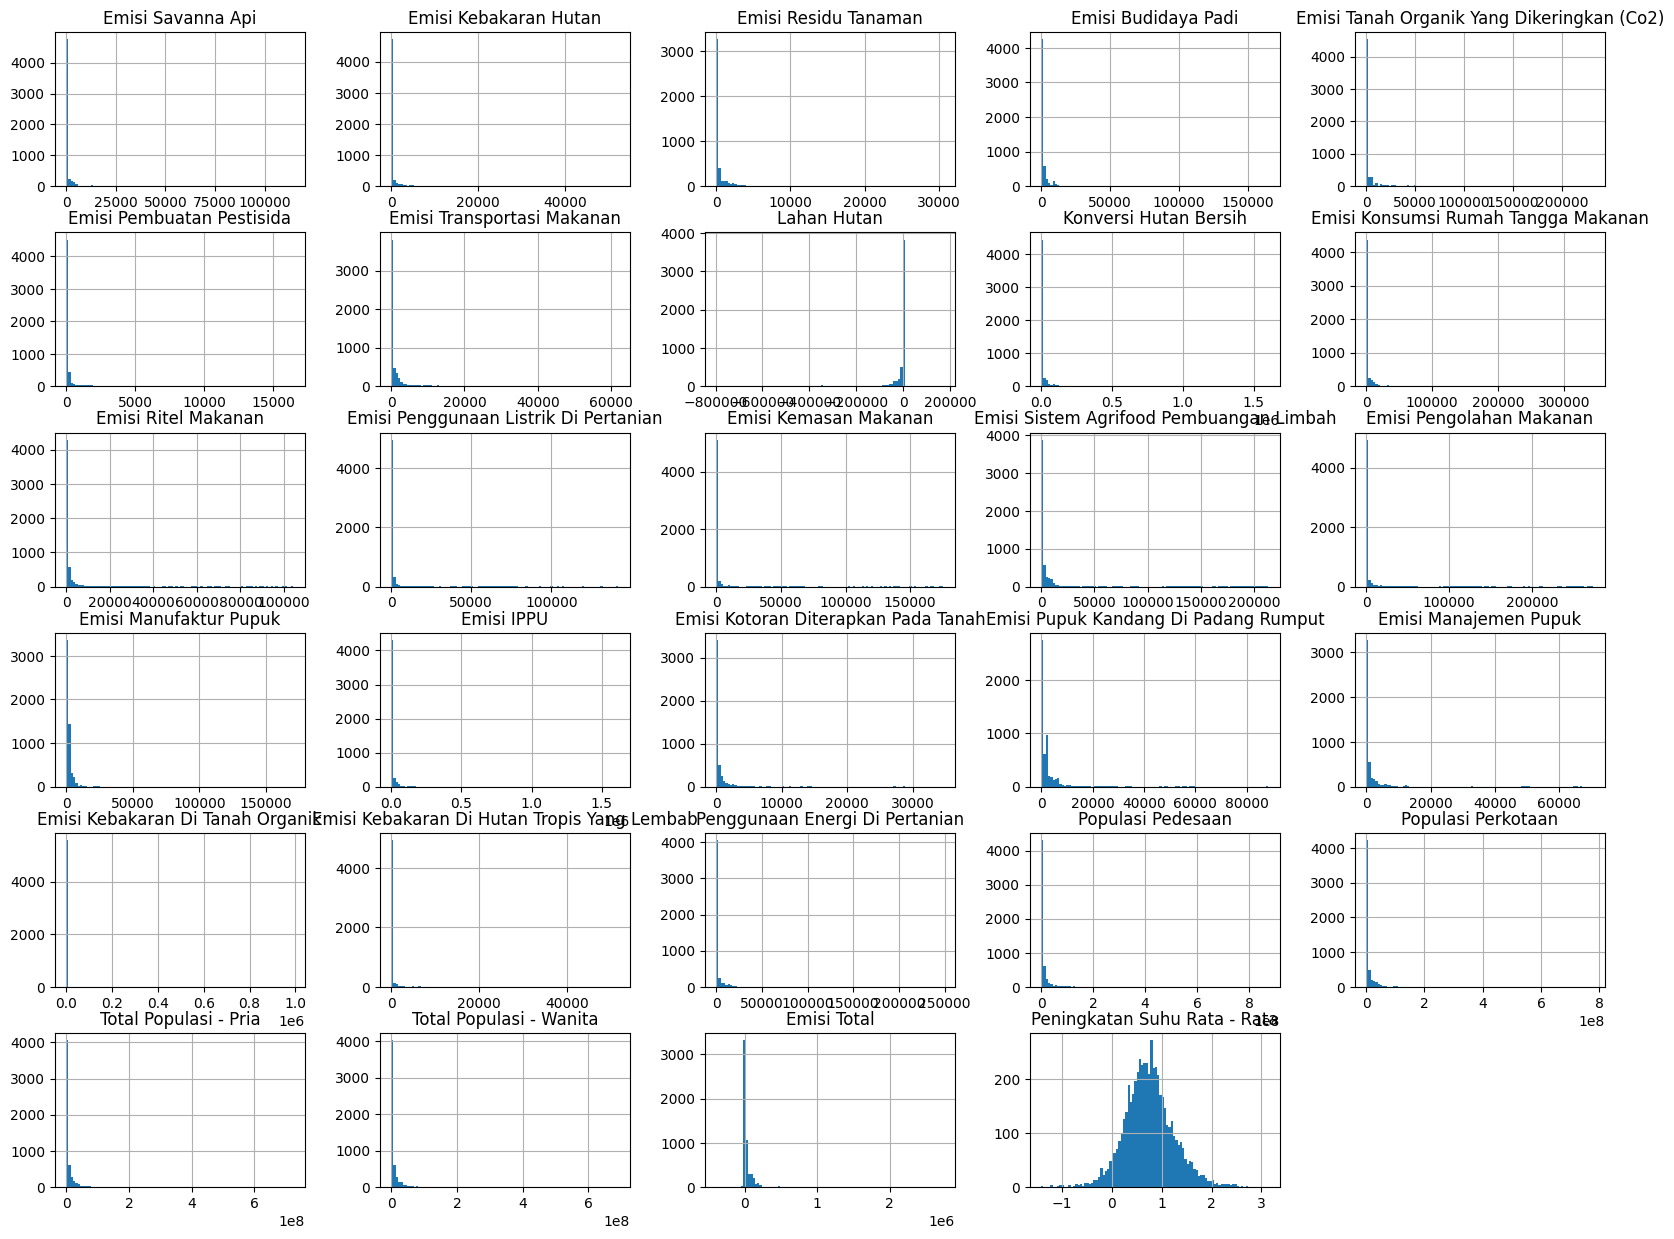

In [155]:
df.hist(bins=100 ,figsize=(20,15))
plt.show()

##### Hanya 1 variabel yang mengikuti distribusi normal, sisanya cenderung skewness ke arah kanan

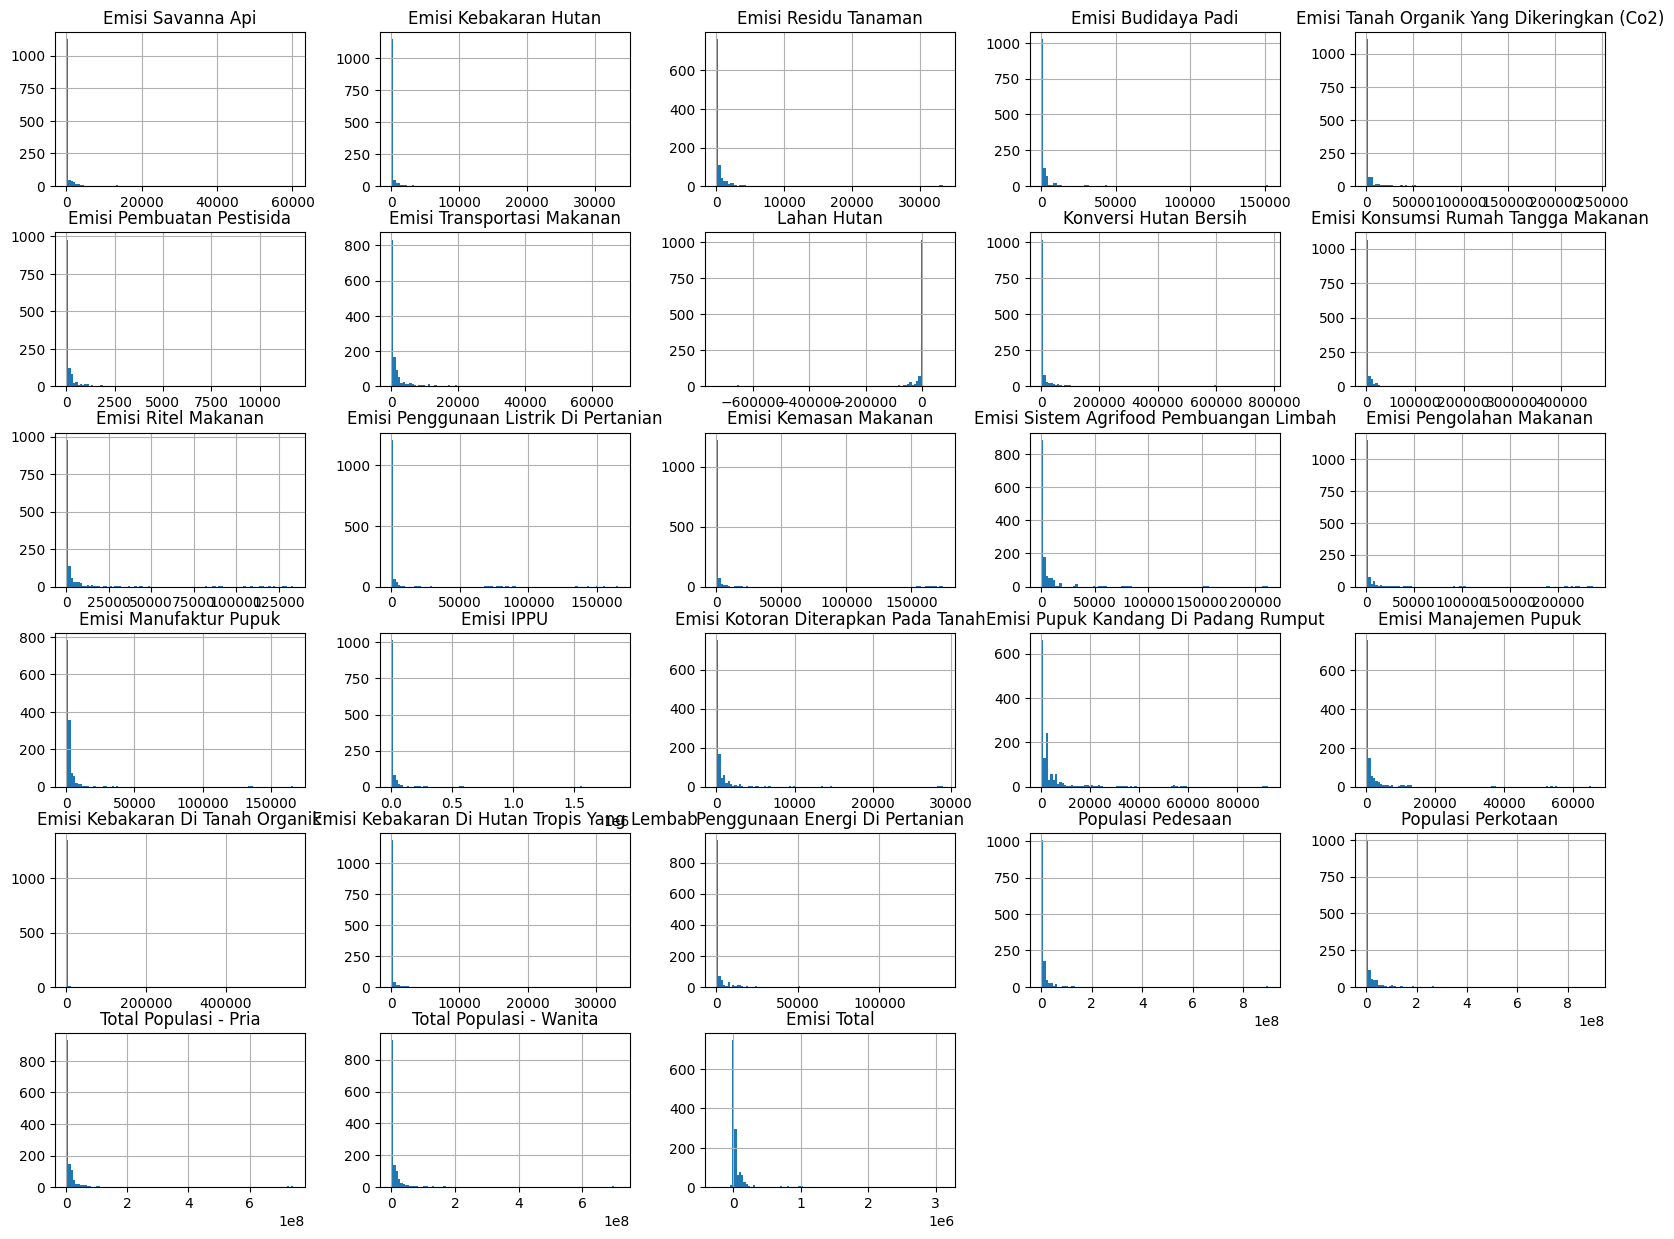

In [156]:
df_test.hist(bins= 100, figsize= (20,15))
plt.show()

### Pemisahan Kolom "Negara/Tahun" Menjadi "Negara" dan "Tahun" pada Dataset Asli

In [157]:
# Pastikan kolom 'Negara/Tahun' bertipe string
df['Negara/Tahun'] = df['Negara/Tahun'].astype(str)

# Step 1: Define a function to extract Negara and Tahun safely
def extract_negara_tahun(value):
    if isinstance(value, str) and '/' in value:
        negara, tahun = value.rsplit('/', 1)  # Memisahkan dari belakang untuk menangani kasus tambahan '/'
        return negara.strip(), tahun.strip()
    return None, None

# Step 2: Apply function to extract Negara and Tahun
df[['Negara', 'Tahun']] = df['Negara/Tahun'].apply(lambda x: pd.Series(extract_negara_tahun(x)))

# Convert Tahun to numeric
df['Tahun'] = pd.to_numeric(df['Tahun'], errors='coerce')

# Hapus kolom 'Negara/Tahun'
df.drop(columns=['Negara/Tahun'], inplace=True)

# Cek hasil pemisahan
print(df.head())

   Emisi Savanna Api  Emisi Kebakaran Hutan  Emisi Residu Tanaman  \
0            14.7237                 0.0557              205.6077   
1            14.7237                 0.0557              209.4971   
2            14.7237                 0.0557              196.5341   
3            14.7237                 0.0557              230.8175   
4            14.7237                 0.0557              242.0494   

   Emisi Budidaya Padi  Emisi Tanah Organik Yang Dikeringkan (Co2)  \
0               686.00                                         0.0   
1               678.16                                         0.0   
2               686.00                                         0.0   
3               686.00                                         0.0   
4               705.60                                         0.0   

   Emisi Pembuatan Pestisida  Emisi Transportasi Makanan  Lahan Hutan  \
0                  11.807483                     63.1152    -2388.803   
1                 

### Pemisahan Kolom "Negara/Tahun" Menjadi "Negara" dan "Tahun" pada Dataset Test

In [158]:
# Pastikan kolom 'Negara/Tahun' bertipe string
df_test['Negara/Tahun'] = df_test['Negara/Tahun'].astype(str)

# Step 1: Define a function to extract Negara and Tahun safely
def extract_negara_tahun(value):
    if isinstance(value, str) and '/' in value:
        negara, tahun = value.rsplit('/', 1)  # Memisahkan dari belakang untuk menangani kasus tambahan '/'
        return negara.strip(), tahun.strip()
    return None, None

# Step 2: Apply function to extract Negara and Tahun
df_test[['Negara', 'Tahun']] = df_test['Negara/Tahun'].apply(lambda x: pd.Series(extract_negara_tahun(x)))

# Convert Tahun to numeric
df_test['Tahun'] = pd.to_numeric(df_test['Tahun'], errors='coerce')

# Hapus kolom 'Negara/Tahun'
df_test.drop(columns=['Negara/Tahun'], inplace=True)

# Cek hasil pemisahan
print(df_test.head())

   Emisi Savanna Api  Emisi Kebakaran Hutan  Emisi Residu Tanaman  \
0             0.8454                    0.0              403.3181   
1             1.6558                    0.0              387.6130   
2             0.4015                    0.0              344.6447   
3             0.2008                    0.0              291.7838   
4             7.1050                    0.0              395.2689   

   Emisi Budidaya Padi  Emisi Tanah Organik Yang Dikeringkan (Co2)  \
0             642.8800                                         0.0   
1             466.4800                                         0.0   
2             429.0518                                         0.0   
3             460.7529                                         0.0   
4             499.9176                                         0.0   

   Emisi Pembuatan Pestisida  Emisi Transportasi Makanan  Lahan Hutan  \
0                  81.852555                    440.0315    -246.2191   
1                 

In [159]:
df.head()

,Emisi Savanna Api,Emisi Kebakaran Hutan,Emisi Residu Tanaman,Emisi Budidaya Padi,Emisi Tanah Organik Yang Dikeringkan (Co2),Emisi Pembuatan Pestisida,Emisi Transportasi Makanan,Lahan Hutan,Konversi Hutan Bersih,Emisi Konsumsi Rumah Tangga Makanan,...,Emisi Kebakaran Di Hutan Tropis Yang Lembab,Penggunaan Energi Di Pertanian,Populasi Pedesaan,Populasi Perkotaan,Total Populasi - Pria,Total Populasi - Wanita,Emisi Total,Peningkatan Suhu Rata - Rata,Negara,Tahun
0,14.7237,0.0557,205.6077,686.00,0.0,11.807483,63.1152,-2388.803,0.0,79.0851,...,0.0,NaN,9655167.0,2593947.0,5348387.0,5346409.0,2198.963539,0.536167,Afghanistan,1990
1,14.7237,0.0557,209.4971,678.16,0.0,11.712073,61.2125,-2388.803,0.0,80.4885,...,0.0,NaN,10230490.0,2763167.0,5372959.0,5372208.0,2323.876629,0.020667,Afghanistan,1991
2,14.7237,0.0557,196.5341,686.00,0.0,11.712073,53.3170,-2388.803,0.0,80.7692,...,0.0,NaN,10995568.0,2985663.0,6028494.0,6028939.0,2356.304229,-0.259583,Afghanistan,1992
3,14.7237,0.0557,230.8175,686.00,0.0,11.712073,54.3617,-2388.803,0.0,85.0678,...,0.0,NaN,11858090.0,3237009.0,7003641.0,7000119.0,2368.470529,0.101917,Afghanistan,1993
4,14.7237,0.0557,242.0494,705.60,0.0,11.712073,53.9874,-2388.803,0.0,88.8058,...,0.0,NaN,12690115.0,3482604.0,7733458.0,7722096.0,2500.768729,0.372250,Afghanistan,1994


### Membuat dua list yang berisi nama-nama kolom numerik pada dua dataset

In [160]:
numerical_columns = df.select_dtypes(include=["int64", "float64"]).columns.tolist()
numerical_columns_test = df_test.select_dtypes(include=["int64", "float64"]).columns.tolist()

# Mengisi nilai-nilai kosong

In [161]:
for col in numerical_columns:
    if col != "Peningkatan Suhu Rata - Rata":  # Exclude target column
        df[col] = df[col].fillna(df[col].median())  # Fill with mean
    else:  # For the target column 'churn'
        df[col] = df[col].fillna(df[col].mode()[0])  # Fill with mode (most frequent value)

# Verifying the changes
print(df.isnull().sum())

Emisi Savanna Api                              0
Emisi Kebakaran Hutan                          0
Emisi Residu Tanaman                           0
Emisi Budidaya Padi                            0
Emisi Tanah Organik Yang Dikeringkan (Co2)     0
Emisi Pembuatan Pestisida                      0
Emisi Transportasi Makanan                     0
Lahan Hutan                                    0
Konversi Hutan Bersih                          0
Emisi Konsumsi Rumah Tangga Makanan            0
Emisi Ritel Makanan                            0
Emisi Penggunaan Listrik Di Pertanian          0
Emisi Kemasan Makanan                          0
Emisi Sistem Agrifood Pembuangan Limbah        0
Emisi Pengolahan Makanan                       0
Emisi Manufaktur Pupuk                         0
Emisi IPPU                                     0
Emisi Kotoran Diterapkan Pada Tanah            0
Emisi Pupuk Kandang Di Padang Rumput           0
Emisi Manajemen Pupuk                          0
Emisi Kebakaran Di T

In [162]:
for cols in numerical_columns_test:
    df_test[cols] = df_test[cols].fillna(df_test[cols].median())  # Fill with mean
print(df_test.isnull().sum())

Emisi Savanna Api                              0
Emisi Kebakaran Hutan                          0
Emisi Residu Tanaman                           0
Emisi Budidaya Padi                            0
Emisi Tanah Organik Yang Dikeringkan (Co2)     0
Emisi Pembuatan Pestisida                      0
Emisi Transportasi Makanan                     0
Lahan Hutan                                    0
Konversi Hutan Bersih                          0
Emisi Konsumsi Rumah Tangga Makanan            0
Emisi Ritel Makanan                            0
Emisi Penggunaan Listrik Di Pertanian          0
Emisi Kemasan Makanan                          0
Emisi Sistem Agrifood Pembuangan Limbah        0
Emisi Pengolahan Makanan                       0
Emisi Manufaktur Pupuk                         0
Emisi IPPU                                     0
Emisi Kotoran Diterapkan Pada Tanah            0
Emisi Pupuk Kandang Di Padang Rumput           0
Emisi Manajemen Pupuk                          0
Emisi Kebakaran Di T

In [163]:
df.describe()

,Emisi Savanna Api,Emisi Kebakaran Hutan,Emisi Residu Tanaman,Emisi Budidaya Padi,Emisi Tanah Organik Yang Dikeringkan (Co2),Emisi Pembuatan Pestisida,Emisi Transportasi Makanan,Lahan Hutan,Konversi Hutan Bersih,Emisi Konsumsi Rumah Tangga Makanan,...,Emisi Kebakaran Di Tanah Organik,Emisi Kebakaran Di Hutan Tropis Yang Lembab,Penggunaan Energi Di Pertanian,Populasi Pedesaan,Populasi Perkotaan,Total Populasi - Pria,Total Populasi - Wanita,Emisi Total,Peningkatan Suhu Rata - Rata,Tahun
count,5603.000000,5603.00000,5603.000000,5603.000000,5603.000000,5603.000000,5603.000000,5603.00000,5.603000e+03,5603.000000,...,5603.000000,5603.000000,5603.000000,5.603000e+03,5.603000e+03,5.603000e+03,5.603000e+03,5.603000e+03,5603.000000,5603.000000
mean,1224.175253,911.91200,779.366514,4241.101704,3471.791570,327.522289,1823.138303,-16864.87244,1.715009e+04,4001.831835,...,1254.336085,653.374878,2613.663669,1.794903e+07,1.573881e+07,1.703881e+07,1.675670e+07,6.057137e+04,0.750170,2002.116723
std,5460.742927,3669.31904,3148.405016,17599.627763,15488.661938,1445.484865,5306.417931,78258.79565,1.042147e+05,19988.380220,...,23189.667834,3208.148456,11537.255759,9.073657e+07,5.920313e+07,7.398219e+07,7.056196e+07,2.084904e+05,0.498943,7.166377
min,0.000000,0.00000,0.000200,0.000000,0.000000,0.000000,0.000100,-797183.07900,0.000000e+00,0.000000,...,0.000000,0.000000,0.031900,0.000000e+00,0.000000e+00,2.700000e+02,3.000000e+02,-3.918841e+05,-1.415833,1990.000000
25%,0.000000,0.00000,24.535950,172.219300,0.000000,5.000000,26.262663,-2492.96230,0.000000e+00,12.174750,...,0.000000,0.000000,16.216850,9.431400e+04,2.045720e+05,1.948370e+05,2.003545e+05,5.135030e+03,0.440333,1996.000000
50%,1.657900,0.66185,98.037400,515.517200,0.000000,12.328281,176.065300,-69.53460,4.461600e+01,136.267400,...,0.000000,0.000000,134.477500,1.572038e+06,2.201558e+06,2.336340e+06,2.338950e+06,1.174802e+04,0.729750,2002.000000
75%,109.114000,67.12410,254.561100,1551.410550,694.164500,106.981731,1135.649750,0.00000,3.830905e+03,1172.529050,...,0.000000,8.195550,859.227050,7.836860e+06,7.690343e+06,8.586906e+06,8.617358e+06,3.292111e+04,1.030167,2008.000000
max,114616.401100,52227.63060,30638.533800,164915.255600,232118.469400,16459.000000,62048.167300,171121.07600,1.605106e+06,344626.339200,...,991717.543100,51771.256800,248879.176900,8.748576e+08,7.799545e+08,7.243639e+08,6.922046e+08,2.741630e+06,3.143000,2014.000000


# Imputasi Menggunakan Berbagai Metode Tergantung Variabel

In [164]:
from sklearn.impute import KNNImputer
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

def impute_numerical(method="mean"):
    for col in numerical_columns:
        if col != "churn":  
            if method == "mean":
                df[col] = df[col].fillna(df[col].mean())
            elif method == "median":
                df[col] = df[col].fillna(df[col].median())
            elif method == "knn":
                knn_imputer = KNNImputer(n_neighbors=5, weights="uniform", metric="nan_euclidean")
                df[numerical_columns] = knn_imputer.fit_transform(df[numerical_columns])
                break  
            elif method == "iterative":
                # Apply Iterative Imputation (MICE)
                iterative_imputer = IterativeImputer(max_iter=10, random_state=0)
                df[numerical_columns] = iterative_imputer.fit_transform(df[numerical_columns])
                break  
            else:
                raise ValueError("Invalid method! Choose 'mean', 'median', 'knn', or 'iterative'.")
        else:
            df[col] = df[col].fillna(df[col].mode()[0])

impute_numerical(method="median")  

print(df.isnull().sum()) 

Emisi Savanna Api                              0
Emisi Kebakaran Hutan                          0
Emisi Residu Tanaman                           0
Emisi Budidaya Padi                            0
Emisi Tanah Organik Yang Dikeringkan (Co2)     0
Emisi Pembuatan Pestisida                      0
Emisi Transportasi Makanan                     0
Lahan Hutan                                    0
Konversi Hutan Bersih                          0
Emisi Konsumsi Rumah Tangga Makanan            0
Emisi Ritel Makanan                            0
Emisi Penggunaan Listrik Di Pertanian          0
Emisi Kemasan Makanan                          0
Emisi Sistem Agrifood Pembuangan Limbah        0
Emisi Pengolahan Makanan                       0
Emisi Manufaktur Pupuk                         0
Emisi IPPU                                     0
Emisi Kotoran Diterapkan Pada Tanah            0
Emisi Pupuk Kandang Di Padang Rumput           0
Emisi Manajemen Pupuk                          0
Emisi Kebakaran Di T

In [165]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5603 entries, 0 to 5602
Data columns (total 31 columns):
 #   Column                                       Non-Null Count  Dtype  
---  ------                                       --------------  -----  
 0   Emisi Savanna Api                            5603 non-null   float64
 1   Emisi Kebakaran Hutan                        5603 non-null   float64
 2   Emisi Residu Tanaman                         5603 non-null   float64
 3   Emisi Budidaya Padi                          5603 non-null   float64
 4   Emisi Tanah Organik Yang Dikeringkan (Co2)   5603 non-null   float64
 5   Emisi Pembuatan Pestisida                    5603 non-null   float64
 6   Emisi Transportasi Makanan                   5603 non-null   float64
 7   Lahan Hutan                                  5603 non-null   float64
 8   Konversi Hutan Bersih                        5603 non-null   float64
 9   Emisi Konsumsi Rumah Tangga Makanan          5603 non-null   float64
 10  

# Reduksi Dimensi
##### Tujuannya karena fokus utama analisis dataset ini untuk memahami tren global dan tidak spesifik satu negara

In [166]:
df = df.drop(columns=["Negara"])
df_test = df_test.drop(columns=["Negara"])

# Visualiasi Heatmap

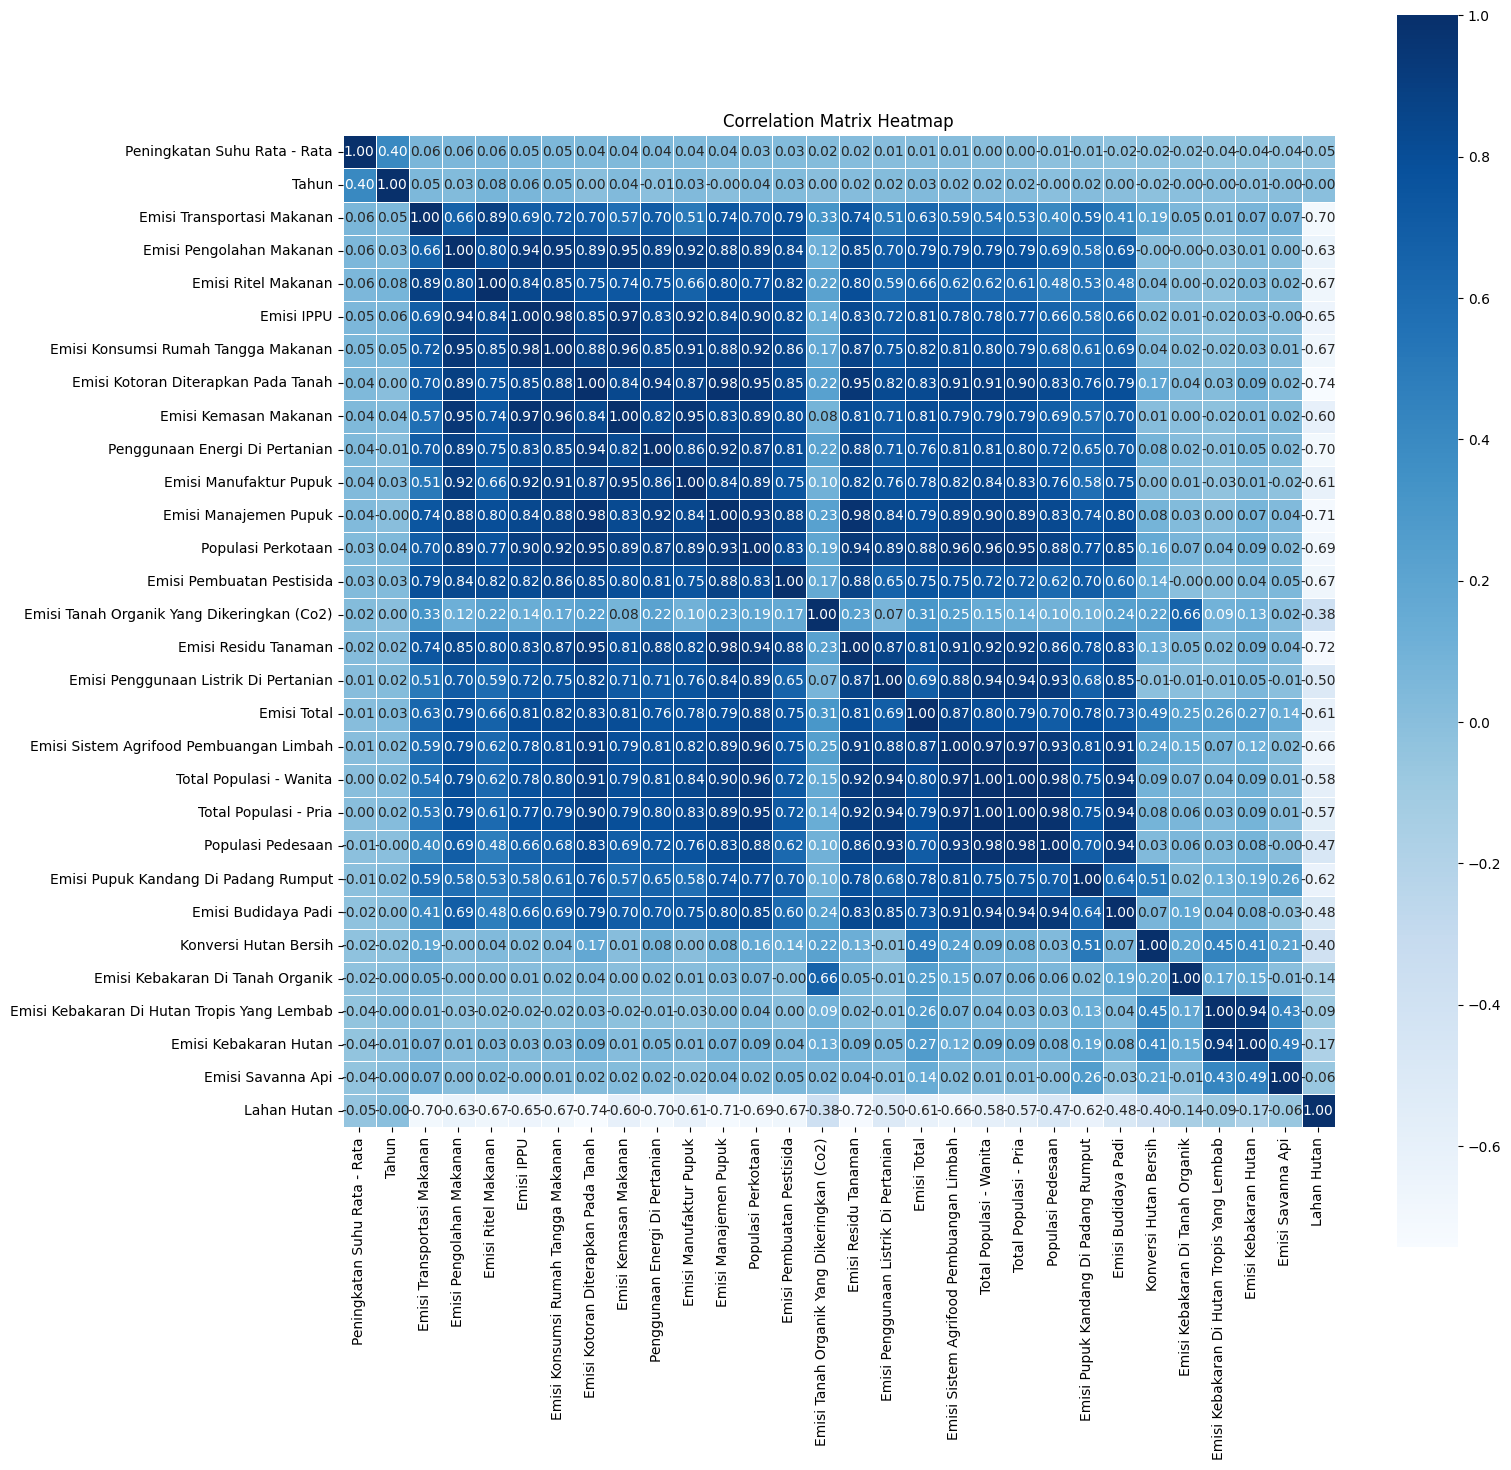

In [167]:
corr_matrix = df.corr()

sorted_correlation = corr_matrix["Peningkatan Suhu Rata - Rata"].sort_values(ascending=False)

correlated_columns = sorted_correlation.index

subset_corr_matrix = corr_matrix.loc[correlated_columns, correlated_columns]

plt.figure(figsize=(16,16))

sns.heatmap(subset_corr_matrix, annot= True, cmap='Blues', linewidths=0.5, fmt=".2f", square= True)

plt.title("Correlation Matrix Heatmap")

plt.show()

##### Menunjukkan seberapa kuat korelasi antara setiap kolom numerik dengan variabel "Peningkatan Suhu Rata - Rata"

In [168]:
x = df.drop(columns=['Peningkatan Suhu Rata - Rata'])
y = df['Peningkatan Suhu Rata - Rata']

In [169]:
x_test = df_test

In [170]:
from sklearn.model_selection import train_test_split
x_train, x_val, y_train, y_val = train_test_split(x, y, test_size=0.2, random_state= 27229)

In [171]:
len(x_train)

4482

In [172]:
len(x_val)

1121

In [173]:
len(y_train)

4482

In [174]:
len(y_val)

1121

In [175]:
from xgboost import XGBRegressor
XGB = XGBRegressor(random_state = 27229)
XGB.fit(x_train, y_train)
y_pred = XGB.predict(x_val)

In [176]:
SEED = 27229

xgboost_params = {
    'max_depth': 10, 
    'verbosity': 0,
    'random_state':SEED,
    'booster': 'gbtree',
    'n_estimators': 1137, 
    'tree_method': 'hist',
    'max_bin': 2048,
    'min_child_weight': 7, 
    'grow_policy': 'lossguide', 
    'gamma': 0.03816426816838989, 
    'subsample': 0.486382907668344, 
    'objective': 'reg:squarederror',
    'reg_lambda': 1.7487237399420372, 
    'reg_alpha': 0.013043045359306716,
    'learning_rate': 0.011733966748427322, 
    'colsample_bytree': 0.5748511749872887, 
    'max_bin': 2048
}

In [177]:
y_true = y_val
y_true.info()

<class 'pandas.core.series.Series'>
Index: 1121 entries, 1221 to 1234
Series name: Peningkatan Suhu Rata - Rata
Non-Null Count  Dtype  
--------------  -----  
1121 non-null   float64
dtypes: float64(1)
memory usage: 17.5 KB


In [178]:
def mape(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

In [179]:
mape(y_true, y_pred)

np.float64(119.43033790851037)

In [180]:

y_pred_table = pd.DataFrame(y_pred)
y_pred_table

,0
0,0.240173
1,0.734952
2,1.278858
3,-0.082715
4,0.764106
...,...
1116,0.716656
1117,1.503075
1118,0.697082
1119,0.113034


In [181]:
import joblib

joblib.dump(XGB, 'coba.pkl')

['coba.pkl']

In [182]:
len(x_test)

1362

In [183]:
test_ids = pd.read_csv("C:/Uner/Lomba/ArcVidya/Warm up/test.csv")["id"]

loaded_model = joblib.load('coba.pkl')

predicted = loaded_model.predict(x_test)

test_result_df = pd.DataFrame({'id': test_ids, 'Peningkatan Suhu Rata - Rata ° C': predicted.flatten()})
test_result_df.to_csv('hasil.csv', index=False)